N= 2, τ=0.010, ergotropy = 1.999400, variance = 0.000600, Erg / <EB> =1.000000
N= 4, τ=0.010, ergotropy = 3.998000, variance = 0.002000, Erg / <EB> =1.000000
N= 6, τ=0.010, ergotropy = 5.995800, variance = 0.004201, Erg / <EB> =1.000000
N= 8, τ=0.010, ergotropy = 7.992800, variance = 0.007202, Erg / <EB> =1.000000
N=10, τ=0.010, ergotropy = 9.989000, variance = 0.011006, Erg / <EB> =1.000000
N=12, τ=0.010, ergotropy = 11.984400, variance = 0.015611, Erg / <EB> =1.000000
N=14, τ=0.010, ergotropy = 13.979000, variance = 0.021019, Erg / <EB> =1.000000
N=16, τ=0.010, ergotropy = 15.972800, variance = 0.027230, Erg / <EB> =1.000000
N=18, τ=0.010, ergotropy = 17.965800, variance = 0.034245, Erg / <EB> =1.000000
N=20, τ=0.010, ergotropy = 19.958000, variance = 0.042063, Erg / <EB> =1.000000
N=22, τ=0.010, ergotropy = 21.949400, variance = 0.050686, Erg / <EB> =1.000000
N=24, τ=0.010, ergotropy = 23.940000, variance = 0.060114, Erg / <EB> =1.000000
N=26, τ=0.010, ergotropy = 25.929800, varianc

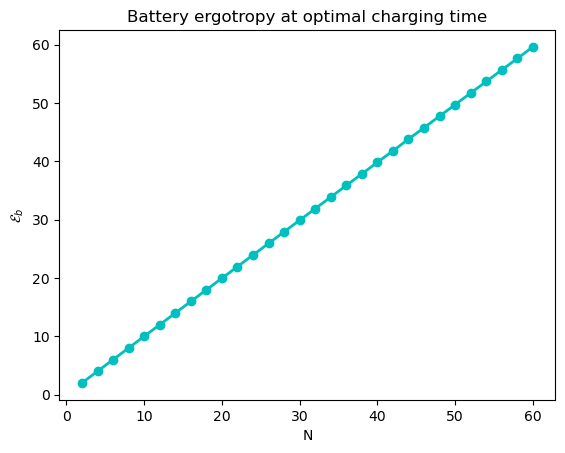

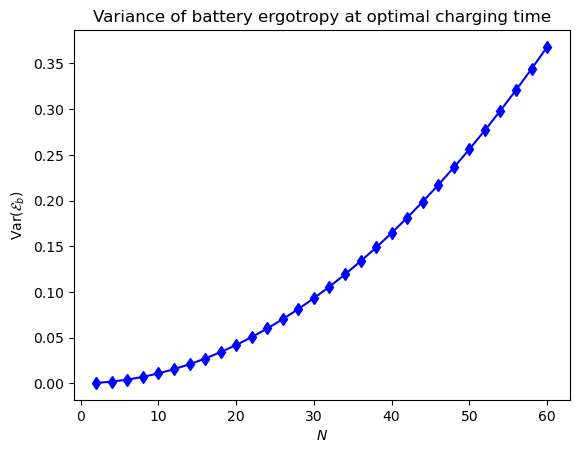

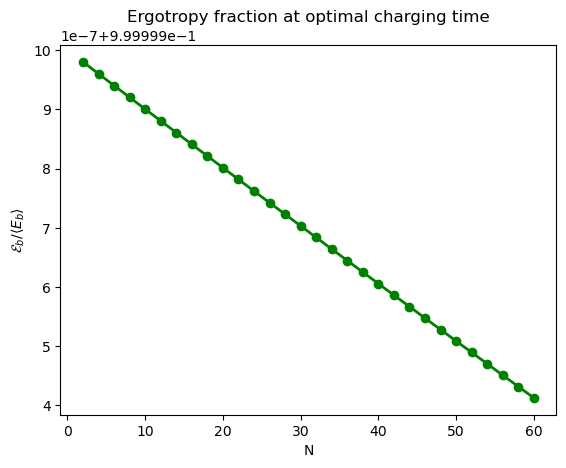

In [37]:
import numpy as np
import qutip as qt
import matplotlib.pyplot as plt

############
# parameters
############

N_arr = np.arange(2, 62, 2)
nmax = 100
ω = 1.0
ω0 = 1.0
g = 1.0
tlist = np.arange(0.01, (2*np.pi), 0.1)

######################
# collective operators
######################

def collective_ops(N):
    Sp = qt.jmat(N/2, '+')
    Sm = Sp.dag()
    Sz = qt.jmat(N/2, 'z')
    HB = Sz + (N/2)*qt.qeye(N+1)
    return Sp, Sm, HB

############################
# Tavis-Cummings Hamiltonian
############################

def tavis_cummings(N, nmax, ω, ω0, g):
    a = qt.destroy(nmax)
    Sp, Sm, HB = collective_ops(N)
    H = (ω * qt.tensor(a.dag()*a, qt.qeye(N+1)) + ω0 * qt.tensor(qt.qeye(nmax), HB) + g * (qt.tensor(a, Sp) + qt.tensor(a.dag(), Sm)))
    return H, HB

################
# Initial state
################

def initial_state(N, nmax, state):
    if state=="coherent":
        psiA = qt.coherent(nmax, np.sqrt(N))
    elif state=="fock":
        psiA = qt.basis(nmax, N)
    psiB = qt.basis(N+1, 0)  
    return qt.tensor(psiA, psiB)

#########################################
# optimal charging time τ (maximum power)
#########################################

τ_list = []

for N in N_arr:
    H, HB = tavis_cummings(N, nmax, ω, ω0, g)
    HB_full = qt.tensor(qt.qeye(nmax), HB)
    psi0 = initial_state(N, nmax, "coherent")

    res = qt.sesolve(H, psi0, tlist, e_ops=HB_full)
    EB = np.array(res.expect[0])
    power = EB / tlist

    τ_list.append(tlist[np.argmax(power)])

###########################################
# Calculation of ergotropy and fluctuations
###########################################

E_ratio, E_ergo, E_var, F_ratio = [], [], [], []

for i, N in enumerate(N_arr):

    τ = τ_list[i]
    
    H, HB = tavis_cummings(N, nmax, ω, ω0, g)
    
    psi0 = initial_state(N, nmax, "coherent")

    res = qt.sesolve(H, psi0, [0, τ])
    
    rho_b = res.states[-1].proj().ptrace(1)

    E_B = qt.expect(HB, rho_b)
    
    r_vals, r_vecs = rho_b.eigenstates()
    
    r_vecs = np.sort(rho_b.eigenenergies())[::-1]
    
    # Passive Hamiltonian constructed in the passive state's eigenbasis
    
    e_vals, e_vecs = HB.eigenstates()
    
    H_passive = sum(e_vals[i] * r_vecs[i] * r_vecs[i].conj().T for i in range(len(e_vals)))

    # Ergotropy operator defined w.r.t. passive Hamiltonian
    
    E_op = HB - H_passive
    
    E_B = qt.expect(HB, rho_b)
    
    E_erg = qt.expect(E_op, rho_b)

    ΔE2 = qt.expect(E_op**2, rho_b) - E_erg**2
    
    ΔE = np.sqrt(qt.expect(E_op**2, rho_b) - E_erg**2)

    E_ergo.append(E_erg)

    E_var.append(ΔE2)
    
    E_ratio.append(E_erg / E_B)
    
    F_ratio.append(ΔE / E_erg)

for idx, N in enumerate(N_arr):
    print(f"N={N:2d}, τ={τ_list[idx]:.3f}, ergotropy = {E_ergo[idx]:.6f}, variance = {E_var[idx]:.6f}, Erg / <EB> ={E_ratio[idx]:.6f}")

###############################################################
# Plot of battery ergotropy at optimal charging for different N 
###############################################################

plt.plot(N_arr, E_ergo, 'o-', color='c', linewidth=2)
plt.xlabel("N")
plt.ylabel(r"$\mathcal{E}_b$")
plt.title("Battery ergotropy at optimal charging time")
plt.show()

###########################################################################
# Plot of variance of battery ergotropy at optimal charging for different N 
###########################################################################

plt.figure()
plt.plot(N_arr, E_var, 'd-', color='b')
plt.xlabel(r"$N$")
plt.ylabel(r"$\mathrm{Var}(\mathcal{E}_b)$")
plt.title("Variance of battery ergotropy at optimal charging time")
plt.show()

##########################################################
# Plot ergotropy fraction as function of g for different N 
##########################################################

plt.plot(N_arr, E_ratio, 'o-', color='g', linewidth=2)
plt.xlabel("N")
plt.ylabel(r"$\mathcal{E}_b / \langle E_b \rangle$")
plt.title("Ergotropy fraction at optimal charging time")
plt.show()

N= 2, τ=0.010, Relative Fluctuation =0.012250
N= 4, τ=0.010, Relative Fluctuation =0.011186
N= 6, τ=0.010, Relative Fluctuation =0.010810
N= 8, τ=0.010, Relative Fluctuation =0.010618
N=10, τ=0.010, Relative Fluctuation =0.010502
N=12, τ=0.010, Relative Fluctuation =0.010426
N=14, τ=0.010, Relative Fluctuation =0.010371
N=16, τ=0.010, Relative Fluctuation =0.010331
N=18, τ=0.010, Relative Fluctuation =0.010300
N=20, τ=0.010, Relative Fluctuation =0.010276
N=22, τ=0.010, Relative Fluctuation =0.010257
N=24, τ=0.010, Relative Fluctuation =0.010241
N=26, τ=0.010, Relative Fluctuation =0.010229
N=28, τ=0.010, Relative Fluctuation =0.010218
N=30, τ=0.010, Relative Fluctuation =0.010210
N=32, τ=0.010, Relative Fluctuation =0.010202
N=34, τ=0.010, Relative Fluctuation =0.010196
N=36, τ=0.010, Relative Fluctuation =0.010191
N=38, τ=0.010, Relative Fluctuation =0.010187
N=40, τ=0.010, Relative Fluctuation =0.010184
N=42, τ=0.010, Relative Fluctuation =0.010181
N=44, τ=0.010, Relative Fluctuatio

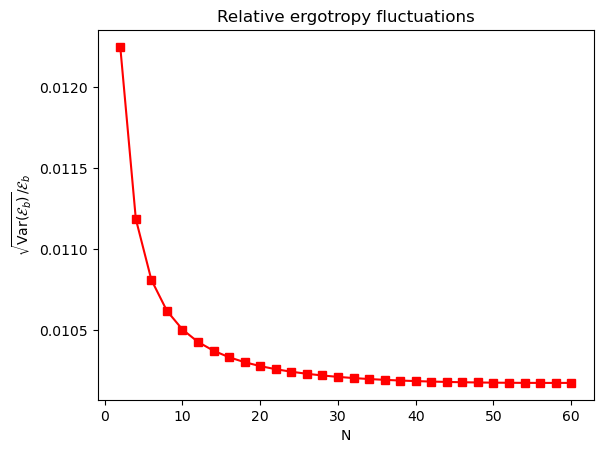

In [39]:
######################################################
# Plot fluctuations as a function of g for different N 
######################################################

for idx, N in enumerate(N_arr):
    print(f"N={N:2d}, τ={τ_list[idx]:.3f}, Relative Fluctuation ={F_ratio[idx]:.6f}")


plt.plot(N_arr, F_ratio, 's-', color='r')
plt.xlabel("N")
plt.ylabel(r"$\sqrt{\mathrm{Var}(\mathcal{E}_b)}/\mathcal{E}_b$")
plt.title("Relative ergotropy fluctuations")
plt.show()

In [19]:
################################################################
# commutator test: ρ is diagonal or not in the energy eigenbasis
################################################################

comm = rho_b * HB - HB * rho_b
comm_norm = comm.norm()
print("[rho, HB] =", comm_norm)

[rho, HB] = 1.1823991572618398


In [20]:
##################################
# numerical degeneracy check of HB 
##################################

e_vals = np.array(HB.eigenenergies())
tol = 1e-10

degenerate_levels = []
for i in range(len(e_vals)-1):
    if abs(e_vals[i+1] - e_vals[i]) < tol:
        degenerate_levels.append((i, i+1))

print("Degenerate pairs:", degenerate_levels)

Degenerate pairs: []


In [21]:
#######################
# Diagonalization of HB
#######################
e_vals, e_vecs = HB.eigenstates()

######################################
# unitary matrix U (energy eigenbasis)
######################################

U = qt.Qobj(np.column_stack([v.full() for v in e_vecs]), dims=HB.dims)

##############################
# Rotate rho into energy basis
##############################

rho_energy = U.dag() * rho_b * U

M = np.abs(rho_energy.full())
np.fill_diagonal(M, 0)
print("Max off-diagonal element:", M.max())

Max off-diagonal element: 0.4153154653432084


In [22]:
##########################################
# non-zero values of off-diagonal elements
##########################################

rho_mat = rho_energy.full()
dim = rho_mat.shape[0]

tol = 1e-10  # numerical threshold
offdiag_entries = []

for i in range(dim):
    for j in range(dim):
        if i != j and abs(rho_mat[i, j]) > tol:
            offdiag_entries.append((i, j, rho_mat[i, j]))

print(f"Number of non-zero off-diagonal elements: {len(offdiag_entries)}")

# Print the non-zero values

offdiag_entries_sorted = sorted(
    offdiag_entries, key=lambda x: abs(x[2]), reverse=True
)

for i, j, val in offdiag_entries_sorted[:20]:
    print(f"(i={i}, j={j})  |ρ|={abs(val):.3e}  phase={np.angle(val):+.2f}")


Number of non-zero off-diagonal elements: 156
(i=59, j=60)  |ρ|=4.153e-01  phase=-1.56
(i=60, j=59)  |ρ|=4.153e-01  phase=+1.56
(i=58, j=60)  |ρ|=1.742e-01  phase=-3.12
(i=60, j=58)  |ρ|=1.742e-01  phase=+3.12
(i=58, j=59)  |ρ|=1.077e-01  phase=-1.56
(i=59, j=58)  |ρ|=1.077e-01  phase=+1.56
(i=57, j=60)  |ρ|=5.917e-02  phase=+1.60
(i=60, j=57)  |ρ|=5.917e-02  phase=-1.60
(i=57, j=59)  |ρ|=3.718e-02  phase=-3.12
(i=59, j=57)  |ρ|=3.718e-02  phase=+3.12
(i=56, j=60)  |ρ|=1.725e-02  phase=+0.04
(i=60, j=56)  |ρ|=1.725e-02  phase=-0.04
(i=57, j=58)  |ρ|=1.637e-02  phase=-1.56
(i=58, j=57)  |ρ|=1.637e-02  phase=+1.56
(i=56, j=59)  |ρ|=1.102e-02  phase=+1.60
(i=59, j=56)  |ρ|=1.102e-02  phase=-1.60
(i=56, j=58)  |ρ|=4.927e-03  phase=-3.12
(i=58, j=56)  |ρ|=4.927e-03  phase=+3.12
(i=55, j=60)  |ρ|=4.460e-03  phase=-1.52
(i=60, j=55)  |ρ|=4.460e-03  phase=+1.52


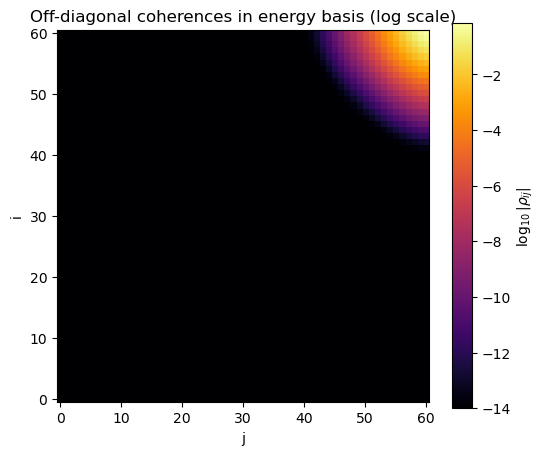

In [23]:
#####################################################
# Off-diagonal coherences in energy basis (log scale)
#####################################################

plt.figure(figsize=(6, 5))
plt.imshow(
    np.log10(np.abs(rho_mat) + 1e-14),
    cmap="inferno",
    origin="lower"
)
plt.colorbar(label=r"$\log_{10}|\rho_{ij}|$")
plt.title("Off-diagonal coherences in energy basis (log scale)")
plt.xlabel("j")
plt.ylabel("i")
plt.show()
